# EDA of SSVEP signals by Kacper Szmigielski

## SSVEP signals


[ENG]

A Steady-State Visual Evoked Potential (SSVEP) is an electroencephalographic (EEG) response elicited by a visual stimulus flickering at a constant frequency, typically in the range of roughly 3.5–75 Hz (most robust responses are usually obtained between about 6 and 30 Hz). The response manifests as an increase in spectral power (amplitude) at the stimulation frequency — and often at its harmonics — most prominently over the occipital (visual) cortex.

[PL]

Steady-State Visual Evoked Potential (SSVEP) to odpowiedź elektroencefalograficzna (EEG) mózgu wywołana bodźcem wzrokowym migoczącym ze stałą częstotliwością, zwykle w zakresie około 3,5–75 Hz (najsilniejsze odpowiedzi uzyskuje się zazwyczaj między 6 a 30 Hz). Reakcja objawia się wzrostem mocy widmowej (amplitudy) na częstotliwości stymulacji — a często również na jej harmonicznych — najwyraźniej widocznym nad korą wzrokową (potyliczną).

## Data

[ENG]

Based on our project specifications, the MAMEM dataset was selected for Exploratory Data Analysis (EDA). This dataset aligns well with our requirements due to its limited number of classes, as we intend to use 4 to 6 flickering LEDs corresponding to specific directional commands (left, right, up, down, forward, and back).

The MAMEM Steady-State Visual Evoked Potentials (SSVEP) database contains 256-channel EEG recordings from 11 subjects under flickering-light stimulation, and includes a second experimental dataset. In this second experiment, subjects were exposed to non-overlapping flickering stimuli from five boxes displayed on a monitor, operating at frequencies of 6.66 Hz, 7.5 Hz, 8.57 Hz, 10 Hz, and 12 Hz, while 256-channel EEG data was recorded.

[PL]

Zgodnie ze specyfikacją naszego projektu, do eksploracyjnej analizy danych (EDA) wybrano zbiór danych MAMEM. Zbiór ten dobrze odpowiada naszym wymaganiom ze względu na ograniczoną liczbę klas — planujemy wykorzystać od 4 do 6 migoczących diod LED odpowiadających konkretnym komendom kierunkowym (lewo, prawo, góra, dół, przód, tył).

Baza danych MAMEM Steady-State Visual Evoked Potentials (SSVEP) zawiera 256-kanałowe zapisy EEG od 11 badanych poddanych stymulacji migoczącym światłem i obejmuje również drugi zbiór eksperymentalny. W tym drugim eksperymencie badani byli eksponowani na nienachodzące na siebie migoczące bodźce wyświetlane w pięciu polach na ekranie monitora, o częstotliwościach 6,66 Hz, 7,5 Hz, 8,57 Hz, 10 Hz i 12 Hz, przy jednoczesnej rejestracji 256-kanałowych danych EEG.

## Libraries used

In [100]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from moabb.datasets import MAMEM3
from moabb.paradigms import SSVEP
from scipy.signal import welch
from sklearn.cross_decomposition import CCA
from scipy.signal import cheby1, filtfilt

 [ENG]
 
 We create an instance of the dataset and a paradigm object.
 The MAMEM3 dataset contains EEG recordings from SSVEP experiments.
 The SSVEP paradigm defines how data is retrieved and organized for classification.

 The SSVEP paradigm (moabb.paradigms.SSVEP) is responsible for:
   - epoching (cutting the continuous signal into fragments around event/stimulus markers),
   - band-pass filtering the signal (default fmin-fmax range, in Hz),
   - mapping raw event labels onto classes corresponding to specific 
     stimulation frequencies (e.g. 6.66 Hz, 7.5 Hz, 8.57 Hz, 10 Hz, 12 Hz),
   - standardizing the output data format (X - EEG epochs, y - class labels, 
     metadata - subject/session info), regardless of which SSVEP dataset the data comes from.

 This means the same paradigm object can be applied to different SSVEP datasets
 (MAMEM1, MAMEM2, MAMEM3, Nakanishi2015, etc.), and the resulting data will have
 a consistent structure ready for further classification (e.g. using CCA).



[PL]

 Tworzymy instancję datasetu oraz obiekt paradygmatu.
 Dataset MAMEM3 zawiera nagrania EEG z eksperymentów SSVEP.
 Paradigma SSVEP określa sposób pobierania i organizacji danych dla klasyfikacji.

 Paradygmat SSVEP (moabb.paradigms.SSVEP) odpowiada za:
   - wycięcie epok (fragmentów sygnału) wokół znaczników zdarzeń/bodźców,
   - filtrację pasmowoprzepustową sygnału (domyślnie np. fmin-fmax w Hz),
   - zmapowanie surowych etykiet zdarzeń na klasy odpowiadające 
     konkretnym częstotliwościom stymulacji (np. 6.66 Hz, 7.5 Hz, 8.57 Hz, 10 Hz, 12 Hz),
   - ujednolicenie formatu danych (X - epoki EEG, y - etykiety klas, metadata - info o badanym/sesji),
     niezależnie od tego, z jakiego datasetu SSVEP pochodzą dane.

 Dzięki temu ten sam obiekt paradygmatu można zastosować do różnych datasetów SSVEP
 (MAMEM1, MAMEM2, MAMEM3, Nakanishi2015 itd.), a wynikowe dane będą miały spójną strukturę
 gotową do dalszej klasyfikacji (np. metodą CCA).

In [101]:

dataset = MAMEM3()
paradigm = SSVEP()

Choosing the first None classes from all possible events


Data from first subject

 [ENG]
 
 We fetch the data for the first subject from the dataset.
 X contains EEG trials in the format (trial, channel, samples).
 labels contains the stimulation frequency labels.
 metadata stores additional information about each trial.
 

 [PL]

 Pobieramy dane dla pierwszego użytkownika z datasetu.
 X zawiera triale EEG w formacie (trial, kanał, próbki).
 labels zawiera etykiety częstotliwości stymulacji.
 metadata przechowuje dodatkowe informacje o każdym trialu.

In [129]:

X, labels, metadata = paradigm.get_data(
    dataset=dataset,
    subjects=dataset.subject_list  
)

[ENG]

MAMEM3 uses the 14-channel EPOC montage. For SSVEP, we are primarily interested in
the occipital/parieto-occipital channels O1, O2, P7, P8

128Hz is the sampling frequency of the EEG device used to collect 

[PL]

MAMEM3 korzysta z 14-kanałowego układu EPOC. Dla SSVEP interesują nas przede wszystkim
kanały potyliczne O1, O2, P7, P8

128Hz to częstotliwość próbkowania urządzenia EEG, którego użyto do zebrania danych w MAMEM3

In [130]:

fs = 128


EPOC_CHANNELS = [
    "AF3", "F7", "F3", "FC5", "T7", "P7", "O1",
    "O2", "P8", "T8", "FC6", "F4", "F8", "AF4"
]

OCCIPITAL_CHANNELS = ["O1", "O2", "P7", "P8"]

OCCIPITAL_CHANNELS_INDICES = [
    EPOC_CHANNELS.index(channel) for channel in OCCIPITAL_CHANNELS
]



# Chebyshev bandpass filter

Pafnuty Chebyshev

![Pafnuty Chebyshev](assets/chebycheef.jpg)

[ENG]
   
We calculate the Nyquist frequency (half the sampling frequency).
This is the theoretical upper limit of frequencies that can be properly
reconstructed at the given sampling rate (Nyquist-Shannon theorem).
All filter band edges must be expressed as a fraction of this value.
   
We design a Chebyshev type I filter: an IIR filter with a steep transition
band between the passband and stopband, at the cost of allowed ripple
(ripple_db) in the passband. Returns the filter coefficients b (numerator)
and a (denominator) of the digital filter's transfer function.

We apply the filter in both directions (forward and backward in time),
which eliminates the phase shift normally introduced by IIR filtering.
This matters for EEG, as it preserves accurate timing relationships
between channels.     
     
[PL]

Obliczamy częstotliwość Nyquista (połowa częstotliwości próbkowania).
Jest to teoretyczna górna granica częstotliwości, jaką można poprawnie
odtworzyć przy danej częstotliwości próbkowania (twierdzenie Nyquista-Shannona https://pl.wikipedia.org/wiki/Twierdzenie_o_pr%C3%B3bkowaniu).
Wszystkie granice pasma filtru muszą być podane jako ułamek tej wartości.

Projektujemy filtr Czebyszewa typu I: filtr IIR o stromym zboczu przejścia
między pasmem przepustowym a zaporowym, kosztem dopuszczalnego zafalowania
(ripple_db) w paśmie przepustowym. Zwraca współczynniki b (licznik)
i a (mianownik) transmitancji filtru cyfrowego.

Aplikujemy filtr dwukierunkowo (do przodu i do tyłu w czasie), co eliminuje
przesunięcie fazowe wprowadzane normalnie przez filtrację IIR. Jest to istotne
dla EEG, ponieważ zachowuje dokładne zależności czasowe między kanałami.
    


In [131]:

def cheby_bandpass_filter_signal(
    signal: np.ndarray,
    lowcut: float = 5.0,
    highcut: float = 45.0,
    fs: int = 128,
    order: int = 4,
    ripple_db: float = 0.5,
) -> np.ndarray:
    """Band-pass filters a single EEG channel with a zero-phase Chebyshev type I filter."""
    nyquist = 0.5 * fs
    b, a = cheby1(
        order,
        ripple_db,
        [lowcut / nyquist, highcut / nyquist],
        btype="bandpass",
    )
    return filtfilt(b, a, signal)


In [132]:

def filter_eeg_trials(
    trials: np.ndarray,
    lowcut: float = 5.0,
    highcut: float = 45.0,
    fs: int = 128,
) -> np.ndarray:
    """Applies the same band-pass filter independently to every trial and EEG channel."""
    filtered = np.empty_like(trials, dtype=float)

    for trial_idx, trial in enumerate(trials):
        for channel_idx in range(trial.shape[0]):
            filtered[trial_idx, channel_idx] = cheby_bandpass_filter_signal(
                trial[channel_idx],
                lowcut=lowcut,
                highcut=highcut,
                fs=fs,
            )

    return filtered


X_filtered = filter_eeg_trials(X, lowcut=5.0, highcut=45.0, fs=fs)

X_occipital = X_filtered[:, OCCIPITAL_CHANNELS_INDICES, :]


### Basic dataset features

In [133]:
# Wypisujemy podstawowe informacje o zbiorze danych,
# żeby sprawdzić kształt, liczbę triali i rozkład klas.

#kształt
print(X.shape)



(1375, 14, 385)


In [134]:

#kształ etykiet
print(labels.shape)

(1375,)


In [135]:
#podgląd metadanych
print(metadata.head())


   subject session run
0        1       0   0
1        1       0   0
2        1       0   0
3        1       0   0
4        1       0   0


In [136]:
#liczba klas dla triali
print(pd.Series(labels).value_counts())

8.57     330
7.50     275
10.00    275
12.00    275
6.66     220
Name: count, dtype: int64


As we can see, the trial counts for each frequency are similar, ranging from 20 to 30.

For SSVEP signals, we are most interested in occipital brain signals. In the 14-channel EPOC montage used here, the available occipital electrodes are O1 and O2; Oz and POz are not present.

![Occipital Lobe](assets/Occipital.jpg)


[ENG]

Simple data representations

In this part, I used basic visual representations of the EEG signal to understand its structure before applying classification methods. One of the most important tools was Welch's method, which estimates the Power Spectral Density (PSD) of the signal.

Power Spectral Density shows how the signal's power is distributed across different frequencies. In the context of SSVEP signals, this is especially important because the brain response is expected to show increased power at the frequency of the visual stimulus (e.g., 6.66 Hz), and often at its harmonics as well (e.g., 13.32 Hz, 19.98 Hz).

Welch's method works by dividing the signal into shorter, overlapping segments, computing the periodogram for each segment, and then averaging the results. This reduces the variance of the PSD estimate compared to a single Fourier transform computed over the whole signal, at the cost of frequency resolution — a trade-off controlled by the segment length (nperseg) and overlap parameters.

This averaging makes the PSD estimate more stable and less sensitive to noise, which is essential for reliably identifying the stimulation frequency and its harmonics in the occipital channels (O1, O2, P7, P8).

Reference: [Welch's method — Wikipedia](https://en.wikipedia.org/wiki/Welch%27s_method)

[PL]

W tej części wykorzystałem podstawowe wizualne reprezentacje sygnału EEG, aby zrozumieć jego strukturę przed zastosowaniem metod klasyfikacji. Jednym z najważniejszych narzędzi była metoda Welcha, która estymuje gęstość widmową mocy (Power Spectral Density, PSD) sygnału.

Gęstość widmowa mocy pokazuje, jak moc sygnału jest rozłożona na różne częstotliwości. W kontekście sygnałów SSVEP jest to szczególnie istotne, ponieważ odpowiedź mózgu powinna wykazywać zwiększoną moc na częstotliwości bodźca wzrokowego (np. 6,66 Hz), a często również na jej harmonicznych (np. 13,32 Hz, 19,98 Hz).

Metoda Welcha działa poprzez podzielenie sygnału na krótsze, nachodzące na siebie segmenty, obliczenie periodogramu dla każdego segmentu, a następnie uśrednienie wyników. Zmniejsza to wariancję estymatora PSD w porównaniu do pojedynczej transformaty Fouriera obliczonej na całym sygnale, kosztem rozdzielczości częstotliwościowej — jest to kompromis kontrolowany przez długość segmentu (nperseg) oraz stopień nakładania się segmentów.

Dzięki temu uśrednieniu estymata PSD jest bardziej stabilna i mniej podatna na szum, co jest kluczowe przy wiarygodnej identyfikacji częstotliwości stymulacji i jej harmonicznych w kanałach potylicznych (O1, O2, P7, P8).

Źródło: [Metoda Welcha — Wikipedia](https://en.wikipedia.org/wiki/Welch%27s_method)

Peter D.Welch

<p align="center">
  <img src="assets/Peter_D._Welch.jpg" alt="Peter D. Welch" width="500">
</p>



In [137]:
trial_idx = 1
trial = X_filtered[trial_idx]

current_label = labels[trial_idx]

target_freqs = [6.66, 7.50, 8.57, 10.00, 12.00]


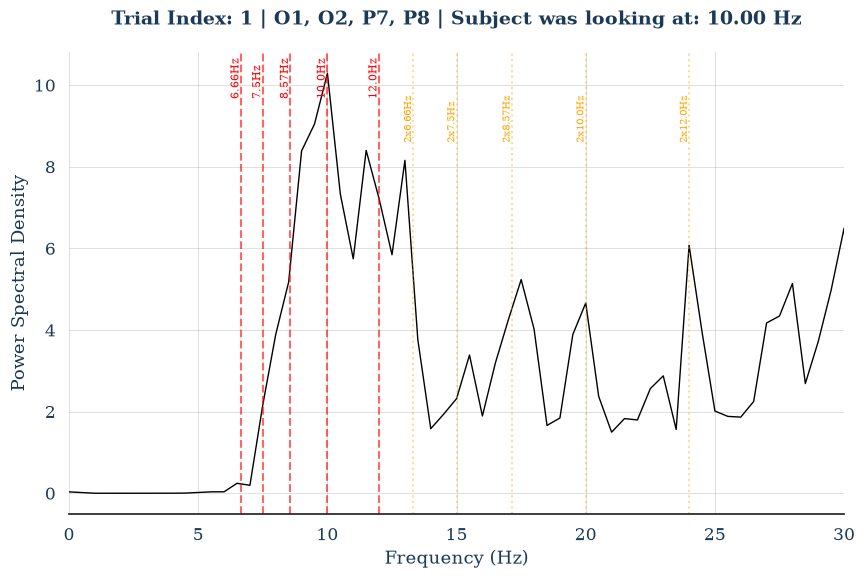

In [138]:

# Liczymy PSD osobno dla O1 i O2, a następnie uśredniamy moce widmowe.
# Nie uśredniamy sygnałów w czasie, żeby nie osłabić odpowiedzi przez różnice fazowe.
occipital_psds = []

for channel_idx in OCCIPITAL_CHANNELS_INDICES:
    freqs, channel_psd = welch(
        trial[channel_idx],
        fs=fs,
        nperseg=fs * 2,
    )
    occipital_psds.append(channel_psd)

psd = np.mean(occipital_psds, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(freqs, psd, color='black', linewidth=1)

# Rysujemy pionowe linie na częstotliwościach stymulacji oraz ich harmonicznych.
for f in target_freqs:
    plt.axvline(x=f, color='red', linestyle='--', alpha=0.6)
    plt.text(f, plt.ylim()[1] * 0.9, f'{f}Hz', rotation=90, color='red', fontsize=8, ha='right')

    h2 = f * 2
    if h2 <= 30:
        plt.axvline(x=h2, color='orange', linestyle=':', alpha=0.4)
        plt.text(h2, plt.ylim()[1] * 0.8, f'2x{f}Hz', rotation=90, color='orange', fontsize=7, ha='right')

plt.title(
    f"Trial Index: {trial_idx} | O1, O2, P7, P8 | Subject was looking at: {current_label} Hz",
    fontsize=14,
    fontweight='bold',
    pad=20,
)

plt.xlim(0, 30)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.show()


[ENG]

After applying Welch's power spectral density (PSD) estimation, a clear peak emerges close to the target stimulation frequency (10 Hz), confirming that the SSVEP response is detectable even at the single-trial level. Some smaller, spurious local maxima are still present elsewhere in the spectrum - expected given the limited signal-to-noise ratio of a single trial - but the dominant peak aligns well with the frequency the subject was actually looking at. This suggests that Welch's method, combined with averaging across the occipital channels, is an effective first step for isolating the SSVEP response, and provides a solid basis for the classification methods applied later.

[PL]

Po zastosowaniu estymacji gęstości widmowej mocy (PSD) metodą Welcha widoczny jest wyraźny pik w okolicy docelowej częstotliwości stymulacji (10 Hz), co potwierdza, że odpowiedź SSVEP jest wykrywalna już na poziomie pojedynczego triala. W widmie pojawiają się też mniejsze, przypadkowe lokalne maksima - czego można się spodziewać przy ograniczonym stosunku sygnału do szumu dla pojedynczej próby - jednak dominujący pik dobrze pokrywa się z częstotliwością, na którą faktycznie patrzył badany. Sugeruje to, że metoda Welcha w połączeniu z uśrednianiem po kanałach potylicznych jest skutecznym pierwszym krokiem do wyodrębnienia odpowiedzi SSVEP i stanowi solidną podstawę pod zastosowane później metody klasyfikacji

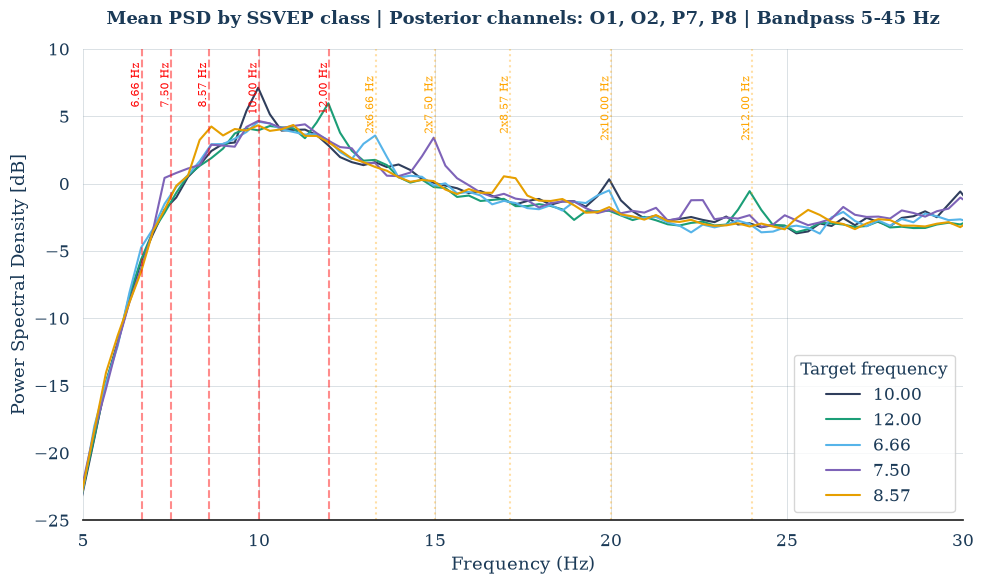

In [159]:
plt.figure(figsize=(10, 6)) 
 
for lab in unique_labels: 
    X_lab = X_filtered[labels == lab] 
 
    psds_db = [] 
 
    for trial in X_lab: 
        trial_occipital_psds = [] 
 
        for channel_idx in OCCIPITAL_CHANNELS_INDICES: 
            freqs, psd = welch( 
                trial[channel_idx], 
                fs=fs, 
                nperseg=trial.shape[1], 
            ) 
            trial_occipital_psds.append(psd) 
 
        trial_psd = np.mean(trial_occipital_psds, axis=0) 
        trial_psd_db = 10 * np.log10(trial_psd + 1e-12) 
        psds_db.append(trial_psd_db) 
 
    class_psd_db = np.median(psds_db, axis=0) 
 
    plt.plot(freqs, class_psd_db, linewidth=1.5, label=str(lab)) 
 
 
# Target frequencies. 
for f in target_freqs: 
    plt.axvline(x=f, color="red", linestyle="--", alpha=0.45) 
    plt.text( 
        f, 
        9, 
        f"{f:.2f} Hz", 
        rotation=90, 
        color="red", 
        fontsize=8, 
        ha="right", 
        va="top", 
    ) 
 
# Second harmonics with labels.
for f in target_freqs:
    h2 = f * 2

    if h2 <= 30:
        plt.axvline(x=h2, color="orange", linestyle=":", alpha=0.35)
        plt.text(
            h2,
            8,
            f"2x{f:.2f} Hz",
            rotation=90,
            color="orange",
            fontsize=8,
            ha="right",
            va="top",
        )
 
 
plt.title( 
    "Mean PSD by SSVEP class | Posterior channels: O1, O2, P7, P8 | Bandpass 5-45 Hz", 
    fontsize=13, 
    fontweight="bold", 
    pad=18, 
) 
 
plt.xlim(5, 30) 
plt.ylim(-25, 10) 
plt.xlabel("Frequency (Hz)") 
plt.ylabel("Power Spectral Density [dB]") 
plt.legend(title="Target frequency") 
plt.grid(True, alpha=0.3) 
plt.tight_layout() 
plt.show()

[ENG]

The plot shows the median power spectral density (PSD) for each SSVEP class using posterior EEG channels O1, O2, P7 and P8 after band-pass filtering in the 5–45 Hz range. The PSD values are displayed in decibels (dB), using a logarithmic transformation of power values. This representation reduces the dominance of very large spectral components and makes smaller class-related peaks easier to inspect visually.

[PL]

Wykres przedstawia medianę gęstości widmowej mocy (PSD) dla każdej klasy SSVEP, obliczoną na podstawie tylnych kanałów EEG: O1, O2, P7 i P8, po filtracji pasmowo-przepustowej w zakresie 5–45 Hz. Wartości PSD zostały przedstawione w skali decybelowej (dB), czyli po transformacji logarytmicznej mocy. Taka reprezentacja zmniejsza dominację bardzo dużych komponentów widmowych i ułatwia wizualną ocenę mniejszych, klasowo-zależnych pików.


[ENG]

To address the limitations of raw spectral decomposition via Welch's method, a Signal-to-Noise Ratio (SNR) metric was employed to quantify the magnitude of the SSVEP response relative to the baseline noise floor. Following power spectral density (PSD) estimation, the SNR was calculated as the ratio of the spectral power at the target stimulation frequency ($f_{target}$) to the mean power of the surrounding frequency bins, excluding the target bin itself:

$$SNR(f_{target}) = \frac{P(f_{target})}{\frac{1}{2K}\sum_{k=1}^{K}\left[P(f_{target}-k\Delta f) + P(f_{target}+k\Delta f)\right]}$$

where $P(f)$ denotes the power at frequency $f$, $\Delta f$ is the frequency resolution of the PSD estimate, and $K$ is the number of neighboring bins considered on each side. In the context of SSVEP decoding, this approach provides an objective, normalized index of stimulus-entrained cortical activity, effectively isolating narrow-band evoked responses from broadband background electroencephalographic (EEG) noise and mitigating individual variations in baseline alpha activity.

[PL]

Aby zaradzić ograniczeniom surowej dekompozycji widmowej metodą Welcha, zastosowano metrykę stosunku sygnału do szumu (Signal-to-Noise Ratio, SNR), która pozwala ilościowo określić wielkość odpowiedzi SSVEP względem poziomu szumu tła. Po estymacji gęstości widmowej mocy (PSD), SNR obliczono jako stosunek mocy widmowej na docelowej częstotliwości stymulacji ($f_{target}$) do średniej mocy w sąsiadujących przedziałach częstotliwości, z wyłączeniem samego przedziału docelowego:

$$SNR(f_{target}) = \frac{P(f_{target})}{\frac{1}{2K}\sum_{k=1}^{K}\left[P(f_{target}-k\Delta f) + P(f_{target}+k\Delta f)\right]}$$

gdzie $P(f)$ oznacza moc na częstotliwości $f$, $\Delta f$ to rozdzielczość częstotliwościowa estymaty PSD, a $K$ to liczba sąsiadujących przedziałów uwzględnianych po każdej stronie. W kontekście dekodowania SSVEP, podejście to zapewnia obiektywny, znormalizowany wskaźnik aktywności korowej powiązanej ze stymulacją, skutecznie izolując wąskopasmowe odpowiedzi ewokowane od szerokopasmowego szumu tła EEG oraz łagodząc indywidualne różnice w aktywności alfa poziomu bazowego.

https://en.wikipedia.org/wiki/Signal-to-noise_ratio

In [163]:
def compute_snr_at_freq(freqs: np.ndarray,
                        psd: np.ndarray,
                        target_freq: float, 
                        noise_width: int = 2, 
                        skip_width: int = 1) -> tuple[float, float]:
    """Computes SNR for a single frequency.

    Args:
        freqs (array_like): Array or list of frequency bins (ints or floats).
        target_freq (float): Target frequency to find.
        psd (array): Power spectral density for a single EEG signal. 
        noise_width  (int): Number of bins to take as noise on each side of the target frequency.
        skip_width (int): Number of adjacent bins to skip on each side of the target frequency.

    Returns
        snr (float) : SNR as the ratio of signal power to noise power. 
        snr_db (float) SNR in decibels
    
    """

    # Sprawdzamy, czy parametry są sensowne.
    if noise_width < 1 or skip_width < 0:
        raise ValueError("noise_width must be >= 1 and skip_width must be >= 0.")
    
    if len(freqs) != len(psd):
        raise ValueError("Length of freqs and psd must be the same.")
    
    if target_freq < 0:
        raise ValueError("target_freq must be non-negative.")

    # Znajdujemy indeks najbliższego binu dla docelowej częstotliwości.
    idx = get_nearest_freq_idx(freqs, target_freq)

    # Moc sygnału w docelowym binie.
    signal_power = psd[idx]

    # Definiujemy zakres binów tła po lewej i prawej stronie docelowego binu.
    left_start = idx - skip_width - noise_width
    left_end = idx - skip_width

    right_start = idx + skip_width + 1
    right_end = idx + skip_width + noise_width + 1

    # Jeśli zakres wychodzi poza tablicę, zwracamy NaN, bo nie da się policzyć sensownego SNR.
    if left_start < 0 or right_end > len(psd):
        return np.nan, np.nan

    # Łączymy biny po lewej i prawej stronie, aby uzyskać szum tła.
    noise_bins = np.concatenate([
        psd[left_start:left_end],
        psd[right_start:right_end]
    ])

    # Średnia moc tła stanowi reprezentację poziomu szumu.
    noise_power = np.mean(noise_bins)

    # Zabezpieczenie przed dzieleniem przez zero (teoretyczny edge case).
    if noise_power == 0:
        return np.nan, np.nan

    # SNR jako stosunek mocy sygnału do mocy tła.
    snr = signal_power / noise_power
    # Zamieniamy na decybele dla wygodniejszej interpretacji.
    snr_db = 10 * np.log10(snr)

    return snr, snr_db

In [164]:
# Tworzymy tabelę z wynikami dla każdej próby (trial) i każdej częstotliwości docelowej.
# SNR liczymy tylko na O1/O2, zamiast uśredniać po wszystkich kanałach EEG.
rows = []

for trial_idx, trial in enumerate(X_filtered):
    true_label = float(labels[trial_idx])
    trial_result = {"trial": trial_idx, "true_label": true_label}

    # PSD liczymy wyłącznie dla kanałów potylicznych, gdzie odpowiedź SSVEP jest najsilniejsza.
    channel_psds = []
    for channel_idx in OCCIPITAL_CHANNELS_INDICES:
        f_bins, psd_vals = welch(
            trial[channel_idx],
            fs=fs,
            nperseg=trial.shape[1],
        )
        channel_psds.append((f_bins, psd_vals))

    # Dla każdej częstotliwości docelowej liczymy SNR po O1/O2.
    for target_freq in target_freqs:
        snrs_for_channels = []
        snrs_db_for_channels = []

        for f_bins, psd_vals in channel_psds:
            snr, snr_db = compute_snr_at_freq(
                freqs=f_bins,
                psd=psd_vals,
                target_freq=target_freq,
                noise_width=2,
                skip_width=1,
            )
            snrs_for_channels.append(snr)
            snrs_db_for_channels.append(snr_db)

        trial_result[f"SNR_{target_freq:.2f}"] = np.nanmean(snrs_for_channels)
        trial_result[f"SNRdB_{target_freq:.2f}"] = np.nanmean(snrs_db_for_channels)

    rows.append(trial_result)

snr_df = pd.DataFrame(rows)

# Wybieramy częstotliwość z największym SNR.
best_col = snr_df[[f"SNR_{f:.2f}" for f in target_freqs]].idxmax(axis=1)
snr_df["predicted_label"] = best_col.str.replace("SNR_", "").astype(float)

snr_df["correct"] = snr_df["true_label"] == snr_df["predicted_label"]


In [166]:
# Liczymy średnią accuracy dla klasyfikatora opartego na SNR.
# To daje nam prosty punkt odniesienia przed przejściem do bardziej zaawansowanego CCA.
accuracy = snr_df["correct"].mean()
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 34.76%


[ENG]

The SNR-based classifier achieved an accuracy of 34.76%, which is above the random chance level of 20% for five classes. This suggests that frequency-specific information is present in the EEG signal, but simple local SNR based on single frequency bins is not sufficient for robust classification. More advanced methods such as CCA and FBCCA are therefore required.

[PL]

Klasyfikator oparty na lokalnym SNR osiągnął accuracy 34.76%, czyli wynik powyżej poziomu losowego dla pięciu klas, który wynosi 20%. Oznacza to, że w sygnale obecna jest pewna informacja zależna od częstotliwości stymulacji, jednak prosta metoda oparta na lokalnym SNR nie wystarcza do stabilnej klasyfikacji. Z tego powodu uzasadnione jest zastosowanie metod CCA i FBCCA.


In [167]:
# Ta komórka generuje referencyjne sygnały sinus/cosinus dla każdego możliwego target_freq.
# W klasycznym CCA porównujemy EEG z tymi wzorcami, bo SSVEP powinien korelować z takimi falami.

def generate_reference_signals(freq, length_sec, fs, n_harmonics=3):
    """Generates sine and cosine reference signals for CCA."""
    # Wektor czasu jest potrzebny do wygenerowania sygnałów o odpowiedniej długości.
    t = np.linspace(0, length_sec, int(fs * length_sec), endpoint=False)
    refs = []
    # Dla każdej harmonicznej tworzymy sinus i cosinus. To pozwala modelowi uchwycić zarówno fazę, jak i zmianę w czasie.
    for h in range(1, n_harmonics + 1):
        refs.append(np.sin(2 * np.pi * h * freq * t))
        refs.append(np.cos(2 * np.pi * h * freq * t))
    return np.array(refs) # Shape: (2 * n_harmonics, samples)

## CCA 

In [168]:
# Definiujemy funkcję liczącą korelację CCA pomiędzy pojedynczym trialem EEG a wzorcem referencyjnym.
# CCA jest używane, bo może znaleźć wspólne składowe między wielokanałowym EEG a wzorcem sygnału.

def get_cca_correlation(data : np.ndarray, ref : np.ndarray) -> float:
    """Computes the maximum canonical correlation between EEG data and reference.
    
        Args:
            data: (channels, samples) EEG data for a single trial.
            ref: (n_refs, samples) Reference signals for a specific frequency (including harmonics

        Returns:
            corr: Maximum canonical correlation coefficient.

    """

    # CCA działa na danych w formie (samples, variables), więc transponujemy wejście EEG.
    X = data.T 
    Y = ref.T
    
    # Ustawiamy 1 komponent. W naszym przypadku liczymy jedną największą korelację.
    cca = CCA(n_components=1)
    X_c, Y_c = cca.fit_transform(X, Y)
    
    # Korelacja między składowymi uzyskanymi przez CCA daje miarę dopasowania do wzorca.
    corr = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]
    return corr

# Druga funkcja do generowania referencyjnych sygnałów, tym razem z bardziej czytelną typizacją.
def generate_reference_signals(freq: float, length_sec: float, fs: int, n_harmonics: int = 3) -> np.ndarray:
    """Generates sine/cosine reference signals for a given stimulus frequency.

    Args:
        freq (float): Target stimulation frequency in Hz.
        length_sec (float): Trial duration in seconds.
        fs (int): Sampling rate in Hz.
        n_harmonics (int): Number of harmonics to include.

    Returns:
        np.ndarray: Reference signals with shape (2 * n_harmonics, n_samples).
    """
    # Przygotowujemy wektor czasu na podstawie częstotliwości próbkowania.
    n_samples = int(fs * length_sec)
    t = np.arange(n_samples) / fs
    refs = []

    # Dla każdej harmonicznej h dodajemy sinus i cosinus.
    for h in range(1, n_harmonics + 1):
        refs.append(np.sin(2 * np.pi * h * freq * t))
        refs.append(np.cos(2 * np.pi * h * freq * t))

    return np.vstack(refs)

In [169]:
# W tej komórce uruchamiamy klasyczny CCA dla każdego trialu.
# Używamy już przefiltrowanych kanałów O1/O2 zamiast całego nieprzefiltrowanego EEG.
length_sec = X_occipital.shape[2] / fs

# Tworzymy słownik referencji dla każdej z docelowych częstotliwości.
references = {
    f: generate_reference_signals(f, length_sec, fs, n_harmonics=3)
    for f in target_freqs
}

results = []

for trial_idx, trial in enumerate(X_occipital):
    correlations = []

    for f in target_freqs:
        ref = references[f]
        rho = get_cca_correlation(trial, ref)
        correlations.append(rho)

    predicted_idx = np.argmax(correlations)
    predicted_freq = target_freqs[predicted_idx]

    results.append({
        "trial": trial_idx,
        "true_label": labels[trial_idx],
        "predicted_label": predicted_freq,
    })

cca_df = pd.DataFrame(results)
cca_df["correct"] = np.isclose(
    cca_df["true_label"].astype(float),
    cca_df["predicted_label"].astype(float),
    atol=0.01,
)

print(f"CCA Accuracy: {cca_df['correct'].mean():.2%}")


CCA Accuracy: 53.53%


In [173]:
cca_df["true_label"] = cca_df["true_label"].astype(float)

cca_df.groupby("true_label")["correct"].mean().sort_index()

true_label
6.66     0.354545
7.50     0.410909
8.57     0.533333
10.00    0.763636
12.00    0.578182
Name: correct, dtype: float64

[ENG]

The class-wise CCA accuracy analysis shows clear differences between the stimulation frequencies. The highest accuracy was obtained for the 10.00 Hz class, reaching 76.36%. The 12.00 Hz and 8.57 Hz classes achieved moderate performance, with accuracies of 57.82% and 53.33%, respectively. Lower performance was observed for 7.50 Hz and 6.66 Hz, with 41.09% and 35.45% accuracy.

These results suggest that SSVEP-related information is present in the EEG signal, but its strength and separability depend strongly on the stimulation frequency. The 10.00 Hz frequency appears to produce the most reliable response in this dataset, while lower frequencies, especially 6.66 Hz and 7.50 Hz, seem less stable and harder to classify.

From the perspective of a practical control system, these results indicate that 10.00 Hz, 12.00 Hz and 8.57 Hz are more promising candidates for command classification. In contrast, 6.66 Hz should be treated with caution, as it may require additional validation or replacement with a more separable stimulation frequency.


[PL]

Analiza skuteczności CCA osobno dla każdej klasy pokazuje istotne różnice między częstotliwościami stymulacji. Najwyższą skuteczność uzyskano dla klasy 10.00 Hz, dla której accuracy wyniosło 76.36%. Klasy 12.00 Hz oraz 8.57 Hz osiągnęły wyniki odpowiednio 57.82% i 53.33%, natomiast najniższą skuteczność zaobserwowano dla 7.50 Hz oraz 6.66 Hz.

Wyniki te sugerują, że odpowiedź SSVEP jest obecna w sygnale EEG, jednak jej siła i separowalność zależą od częstotliwości bodźca. Szczególnie słabsze wyniki dla 6.66 Hz i 7.50 Hz wskazują, że te częstotliwości mogą być mniej stabilne w analizowanym zbiorze danych. Z punktu widzenia projektowania systemu sterowania, częstotliwość 10.00 Hz wydaje się najbardziej wiarygodna, natomiast klasy o niższej skuteczności wymagałyby dalszej walidacji lub zastąpienia innymi częstotliwościami.

After restricting the analysis to O1/O2 and applying the 5–45 Hz band-pass filter, the CCA result above becomes the relevant baseline. Standard CCA already uses sine/cosine references for the fundamental stimulation frequency and its harmonics, but it treats the analysed spectrum as a single band. The next step is Filter Bank CCA (FBCCA), where several filtered subbands are scored separately and then combined with decreasing weights. This usually gives more emphasis to the frequency ranges carrying the fundamental and harmonic SSVEP components while reducing broadband interference.


Next logical step after CCA is to use FBCCA

In [174]:
import numpy as np
import pandas as pd

from scipy.signal import butter, sosfiltfilt
from sklearn.cross_decomposition import CCA


def generate_reference_signals(
    freq: float,
    n_samples: int,
    fs: int,
    n_harmonics: int = 3,
) -> np.ndarray:
    """Generates sine/cosine reference signals for a given stimulus frequency.

    Shape:
        (2 * n_harmonics, n_samples)
    """
    t = np.arange(n_samples) / fs
    refs = []

    for h in range(1, n_harmonics + 1):
        refs.append(np.sin(2 * np.pi * h * freq * t))
        refs.append(np.cos(2 * np.pi * h * freq * t))

    return np.vstack(refs)


def bandpass_filter_signal(
    signal: np.ndarray,
    lowcut: float,
    highcut: float,
    fs: int,
    order: int = 4,
) -> np.ndarray:
    """Band-pass filters a single EEG channel using a zero-phase Butterworth filter."""
    nyq = 0.5 * fs

    if lowcut <= 0:
        raise ValueError("lowcut must be greater than 0.")

    if highcut >= nyq:
        raise ValueError(f"highcut must be lower than Nyquist frequency: {nyq} Hz.")

    sos = butter(
        order,
        [lowcut / nyq, highcut / nyq],
        btype="bandpass",
        output="sos",
    )

    return sosfiltfilt(sos, signal)


def filter_trial_for_subband(
    trial: np.ndarray,
    lowcut: float,
    highcut: float,
    fs: int,
    order: int = 4,
) -> np.ndarray:
    """Applies a band-pass filter independently to every EEG channel in one trial.

    Args:
        trial: EEG trial with shape (n_channels, n_samples).

    Returns:
        Filtered trial with the same shape.
    """
    filtered_trial = np.zeros_like(trial, dtype=float)

    for ch_idx in range(trial.shape[0]):
        filtered_trial[ch_idx] = bandpass_filter_signal(
            signal=trial[ch_idx],
            lowcut=lowcut,
            highcut=highcut,
            fs=fs,
            order=order,
        )

    return filtered_trial


def get_cca_correlation(
    data: np.ndarray,
    ref: np.ndarray,
) -> float:
    """Computes the first canonical correlation between EEG data and reference signals.

    Args:
        data: EEG data with shape (n_channels, n_samples).
        ref: Reference signals with shape (n_reference_signals, n_samples).

    Returns:
        First canonical correlation coefficient.
    """
    X = data.T
    Y = ref.T

    cca = CCA(n_components=1, max_iter=1000)
    X_c, Y_c = cca.fit_transform(X, Y)

    corr = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]

    if np.isnan(corr):
        return 0.0

    return float(corr)


def fbcca_predict(
    trials: np.ndarray,
    true_labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    filter_bands: list[tuple[float, float]] | None = None,
    n_harmonics: int = 3,
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
) -> pd.DataFrame:
    """Predicts SSVEP classes using simplified FBCCA.

    Args:
        trials: EEG trials with shape (n_trials, n_channels, n_samples).
        true_labels: True stimulation frequencies.
        target_freqs: Candidate stimulation frequencies.
        fs: Sampling frequency.
        filter_bands: FBCCA subbands.
        n_harmonics: Number of harmonics used in reference signals.
        filter_order: Butterworth filter order.
        trim_start_sec: Optional time removed from the beginning of each trial.

    Returns:
        DataFrame with trial index, true label, predicted label and correctness.
    """

    # Łagodniejsze pasma niż (6,45), (14,45), (22,45),
    # bo w MAMEM3 mamy niskie częstotliwości: 6.66–12 Hz.
    if filter_bands is None:
        filter_bands = [
            (5, 45),
            (10, 45),
            (15, 45),
        ]

    start_sample = int(trim_start_sec * fs)

    if start_sample > 0:
        trials_used = trials[:, :, start_sample:]
    else:
        trials_used = trials

    n_samples = trials_used.shape[2]

    references = {
        float(freq): generate_reference_signals(
            freq=float(freq),
            n_samples=n_samples,
            fs=fs,
            n_harmonics=n_harmonics,
        )
        for freq in target_freqs
    }

    # Standardowe malejące wagi FBCCA.
    # Pierwszy subband ma największą wagę, kolejne coraz mniejszą.
    weights = np.array([
        (band_idx + 1) ** (-1.25) + 0.25
        for band_idx in range(len(filter_bands))
    ])

    results = []

    for trial_idx, trial in enumerate(trials_used):
        # Filtrujemy trial tylko raz dla każdego subbandu.
        filtered_subbands = []

        for lowcut, highcut in filter_bands:
            filtered_trial = filter_trial_for_subband(
                trial=trial,
                lowcut=lowcut,
                highcut=highcut,
                fs=fs,
                order=filter_order,
            )
            filtered_subbands.append(filtered_trial)

        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            subband_scores = []

            for filtered_trial in filtered_subbands:
                rho = get_cca_correlation(
                    data=filtered_trial,
                    ref=references[target_freq],
                )

                # FBCCA agreguje zwykle rho^2, żeby mierzyć siłę dopasowania.
                subband_scores.append(rho ** 2)

            final_score = np.dot(np.array(subband_scores), weights)
            class_scores[target_freq] = final_score

        predicted_freq = max(class_scores, key=class_scores.get)

        results.append({
            "trial": trial_idx,
            "true_label": float(true_labels[trial_idx]),
            "predicted_label": float(predicted_freq),
            "fbcca_score": float(class_scores[predicted_freq]),
        })

    fbcca_df = pd.DataFrame(results)

    fbcca_df["correct"] = np.isclose(
        fbcca_df["true_label"].astype(float),
        fbcca_df["predicted_label"].astype(float),
        atol=0.01,
    )

    return fbcca_df

In [177]:
# Bierzemy te same kanały tylne co wcześniej, ale z surowego X,
# ponieważ FBCCA samo wykonuje filtrację pasmową przez bank filtrów.
X_posterior_raw = X[:, OCCIPITAL_CHANNELS_INDICES, :]

fbcca_df = fbcca_predict(
    trials=X_posterior_raw,
    true_labels=labels,
    target_freqs=target_freqs,
    fs=fs,
    filter_bands=[
        (5, 45),
        (10, 45),
        (15, 45),
    ],
    n_harmonics=3,
    trim_start_sec=0.0,
)

print(f"FBCCA Accuracy: {fbcca_df['correct'].mean():.2%}")
fbcca_df.head()

FBCCA Accuracy: 55.64%


,trial,true_label,predicted_label,fbcca_score,correct
0,0,7.50,7.5,0.296368,True
1,1,10.00,10.0,0.525713,True
2,2,8.57,10.0,0.267903,False
3,3,6.66,12.0,0.172785,False
4,4,12.00,12.0,0.821900,True


In [179]:
target_freqs_4 = [ 8.57, 10.00, 12.00]

mask_4 = np.isin(labels.astype(float), target_freqs_4)

X_4 = X[mask_4]
labels_4 = labels[mask_4]

X_posterior_raw_4 = X_4[:, OCCIPITAL_CHANNELS_INDICES, :]

fbcca_df_4 = fbcca_predict(
    trials=X_posterior_raw_4,
    true_labels=labels_4,
    target_freqs=target_freqs_4,
    fs=fs,
    filter_bands=[
        (5, 45),
        (10, 45),
        (15, 45),
    ],
    n_harmonics=3,
    trim_start_sec=0.0,
)

print(f"FBCCA 4-class Accuracy: {fbcca_df_4['correct'].mean():.2%}")
fbcca_df_4.groupby("true_label")["correct"].mean().sort_index()

FBCCA 4-class Accuracy: 67.50%


true_label
8.57     0.563636
10.00    0.807273
12.00    0.676364
Name: correct, dtype: float64

In [175]:
print('OCCIPITAL_CHANNELS:', OCCIPITAL_CHANNELS)
print('OCCIPITAL_CHANNELS_INDICES:', OCCIPITAL_CHANNELS_INDICES)
print('X_occipital shape:', X_occipital.shape)


OCCIPITAL_CHANNELS: ['O1', 'O2', 'P7', 'P8']
OCCIPITAL_CHANNELS_INDICES: [6, 7, 5, 8]
X_occipital shape: (1375, 4, 385)


[ENG]

After removing the weakest stimulation frequencies, the FBCCA classifier achieved substantially better performance. In the three-class setting using 8.57 Hz, 10.00 Hz and 12.00 Hz, the accuracy increased to 67.50%, compared to 55.64% in the five-class setup. This result is clearly above the random chance level of 33.33% for three classes.

The class-wise results show that 10.00 Hz was the most reliable frequency, reaching 80.73% accuracy. The 12.00 Hz class also achieved relatively good performance, while 8.57 Hz remained more challenging but still above chance level. These findings indicate that SSVEP class separability strongly depends on the selected stimulation frequencies.

From the perspective of a practical control system, these results suggest that not all available frequencies should be used as control commands. Instead, weaker frequencies such as 6.66 Hz, and potentially 7.50 Hz, should be treated with caution or replaced with more separable frequencies.


[PL]

Po usunięciu najsłabszych częstotliwości skuteczność klasyfikatora FBCCA wyraźnie wzrosła. W wariancie trójklasowym, obejmującym częstotliwości 8.57 Hz, 10.00 Hz oraz 12.00 Hz, accuracy wyniosło 67.50%, podczas gdy w wariancie pięcioklasowym było to 55.64%. Wynik ten jest wyraźnie powyżej poziomu losowego dla trzech klas, który wynosi 33.33%.

Analiza per klasa pokazuje, że najbardziej stabilną częstotliwością była 10.00 Hz, osiągając 80.73% accuracy. Klasa 12.00 Hz również uzyskała relatywnie dobry wynik, natomiast 8.57 Hz była trudniejsza do klasyfikacji, ale nadal znajdowała się powyżej poziomu losowego. Wyniki te sugerują, że separowalność klas SSVEP silnie zależy od doboru częstotliwości stymulacji.

Z perspektywy praktycznego systemu sterowania oznacza to, że nie wszystkie dostępne częstotliwości powinny być automatycznie wykorzystywane jako komendy. Częstotliwości słabsze, szczególnie 6.66 Hz oraz potencjalnie 7.50 Hz, powinny zostać dodatkowo zwalidowane albo zastąpione częstotliwościami o lepszej separowalności.